# HOWTO: Charts and Tables
by [Michael Hahsler](https://michael.hahsler.net)

We will use:

- `matplotlib` can be used to create simple charts (histograms, line charts, etc.). See: https://matplotlib.org/
- `pandas` can be used for data frames (tables).

Install missing packages.

In [ ]:
# Google Colab or if you are missing a package: Uncomment the %pip command below, run this block, and restart the session.
# %pip install -q "numpy>=1.26,<3" "pandas>=2.2,<3" "matplotlib>=3.9,<4" "tabulate>=0.9,<1" "seaborn>=0.13,<1"


## Create some data

In [16]:

import numpy as np  
import pandas as pd

# create some artificial performance data for 3 agents and 100 runs of a O(n^2) algorithm 
# create data for problem size n = 1 .. 100.
n_max = 100
runtime = {
    "agent 1" : np.abs(np.add(np.power(np.divide(range(n_max), 10), 2), 
                              np.random.normal(loc = 0, scale = 10, size = n_max))),
    "agent 2" : np.abs(np.add(np.power(np.divide(range(n_max),  5), 2), 
                              np.random.normal(loc = 0 , scale = 10, size = n_max))),
    "agent 3" : np.abs(np.add(np.power(np.divide(range(n_max), 12), 2), 
                              np.random.normal(loc = 0 , scale = 10, size = n_max)))
}

# show data as a data frame using pandas
df = pd.DataFrame(runtime)
df

,agent 1,agent 2,agent 3
0,6.881371,23.195378,0.713343
1,21.705941,2.300229,4.601221
2,4.418392,6.066748,10.261655
3,14.234376,1.839202,9.064457
4,13.928089,9.214364,1.432918
...,...,...,...
95,84.332266,356.314217,77.187470
96,81.131560,361.684720,75.541826
97,96.016290,371.066914,65.084077
98,101.847015,406.224510,54.128277


In [17]:
# create data for n = 10 and N = 100 replications, so we can compare distributions.
N = 100
performance = {
    "agent 1" : np.add(100, np.random.normal(loc = 0, scale = 10, size = N)),
    "agent 2" : np.add(120, np.random.normal(loc = 0, scale = 20, size = N)),
    "agent 3" : np.add(70,  np.random.normal(loc = 0, scale =  5, size = N))
}

# show data as a data frame using pandas
df = pd.DataFrame(performance)
df

,agent 1,agent 2,agent 3
0,85.625360,124.201957,65.315316
1,107.857739,107.985824,71.315586
2,104.085245,105.605736,67.142997
3,95.687342,115.310279,76.534306
4,100.469361,115.639755,76.488728
...,...,...,...
95,101.441834,136.236369,64.407138
96,94.461926,113.991440,65.489371
97,86.015832,121.944098,64.702113
98,118.173309,150.280161,66.026425


## Charts 

### Line Charts

Plot run time as a function of problem size $n = 1, ...$. This can be used to compare the runtime and look at scalability. In this example, the run time increase with n by $O(n^2)$. Often, you run each size $n$ several times and average the runtime.

In [18]:
import matplotlib.pyplot as plt

# add a grid to the plots
import seaborn as sns 
sns.set_theme(style="whitegrid")

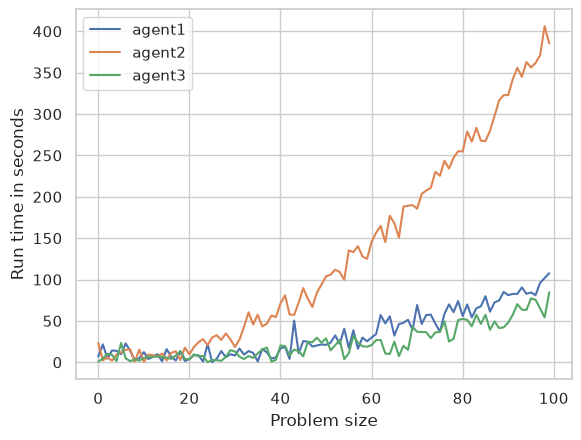

In [19]:
x = range(N)
plt.plot(x, runtime["agent 1"], label = "agent1") 
plt.plot(x, runtime["agent 2"], label = "agent2") 
plt.plot(x, runtime["agent 3"], label = "agent3") 
plt.xlabel("Problem size")
plt.ylabel("Run time in seconds")
plt.legend()
plt.show()

### Scatter plots

Compare $N$ runs of a fixed problem size of $n=10$. Here the runtimes of the two agents are not correlated (because I randomly generated the data). Most of the points are above the diagonal indicating that agent 2 has higher performance.

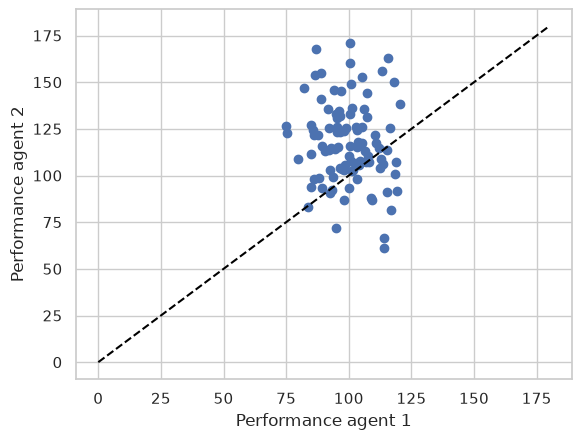

In [20]:
plt.scatter(performance["agent 1"], performance["agent 2"]) 
plt.xlabel("Performance agent 1")
plt.ylabel("Performance agent 2")
plt.plot([0, 180], [0, 180], "--", color = "black")
plt.show()

### Bar plots

Compare the average performance performance.

Mean performance: [ 99.89585572 117.16874037  69.27677254]


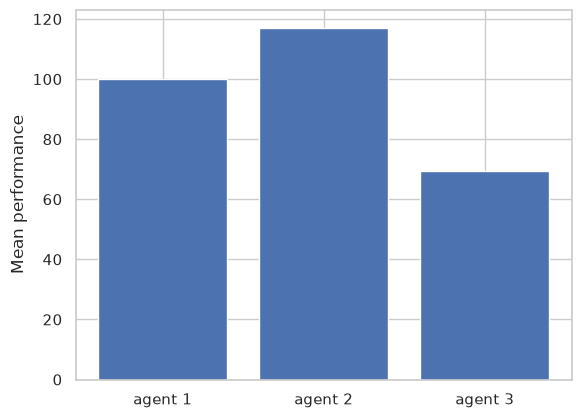

In [21]:
mean_performance = np.mean(list(performance.values()), axis = 1)

print(f"Mean performance: {mean_performance}")

plt.bar(performance.keys(), mean_performance)
plt.ylabel("Mean performance")
plt.show()

### Histograms

Show the distribution of the performance for an agent.

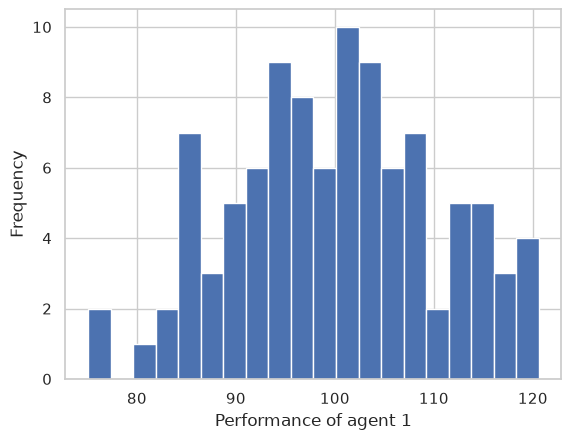

In [22]:
plt.hist(performance["agent 1"], bins = 20)
plt.xlabel("Performance of agent 1")
plt.ylabel("Frequency")
plt.show()

Use histograms to compare the performance distribution between agents.

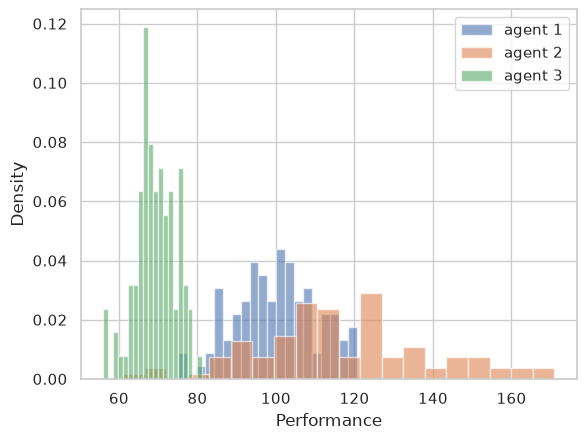

In [23]:
plt.hist(performance["agent 1"], bins = 20, alpha = .6, density=True)
plt.hist(performance["agent 2"], bins = 20, alpha = .6, density=True)
plt.hist(performance["agent 3"], bins = 20, alpha = .6, density=True)
plt.xlabel("Performance")
plt.ylabel("Density")
plt.legend(labels = ["agent 1", "agent 2", "agent 3"])
plt.show()

### Boxplots

Compares distributions using a simplified representation of the histogram as a box (containing the middle 50% of the data) with wiskers. The notches (cutouts) around the median show the 95% confidence interval around the median. If the notches between two boxes do not overlap, then one is significantly better than the other (at a p-value of 0.05). In this case, agent 2 is significantly better than agent 1. 

/tmp/ipykernel_421212/256143766.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bplot = plt.boxplot(list(performance.values()),


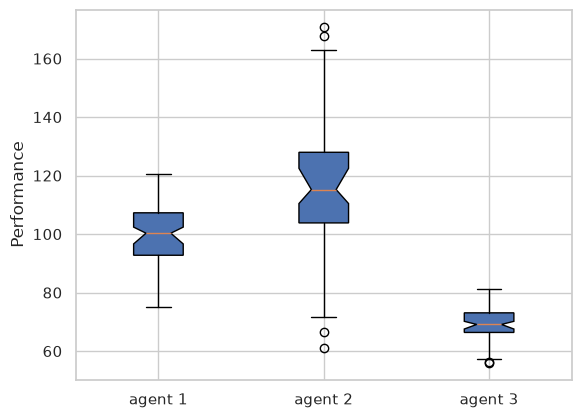

In [24]:
bplot = plt.boxplot(list(performance.values()),
                     notch = True,                 # show 95% confidence intervals around the median
                     bootstrap = 1000,             # used to calculate the notches
                     vert = True,                  # vertical box alignment
                     patch_artist = True,          # fill with color
                     tick_labels = performance.keys())  # will be used to label x-ticks
plt.ylabel("Performance")
plt.show()

## Show Tables

Markdown tables can be produced using markdown syntax (see https://www.markdownguide.org/extended-syntax/):

```
| x   | y    |
| --- | ---- |
| 1.1 | 12.3 |
| 0.8 | 18.0 |
```

Here is the resulting table

| x   | y    |
| --- | ---- |
| 1.1 | 12.3 |
| 0.8 | 18.0 |

Tables in code can be printed in several ways. The easiest is to use `pandas` dataframes. Unfortunately, it cannot print custom row names.

In [25]:
import numpy as np

data = np.array([[1, 2], [3 ,4], [5, 6]])

print(data)



[[1 2]
 [3 4]
 [5 6]]


In [26]:
data_df = pd.DataFrame(data, columns=["x", "y"])
data_df

,x,y
0,1,2
1,3,4
2,5,6


You can also display the table using markdown.

In [27]:
from IPython.display import Markdown, display
display(Markdown(data_df.to_markdown()))

|    |   x |   y |
|---:|----:|----:|
|  0 |   1 |   2 |
|  1 |   3 |   4 |
|  2 |   5 |   6 |